# NLP + Finance: Modeling & Evaluation

This notebook trains and evaluates sentiment classifiers on the Financial PhraseBank dataset. Preprocessing is handled by `src/preprocess.py`.

**Models:** Logistic Regression, Naive Bayes, LinearSVC  
**Baseline:** VADER (zero-shot, no training)  
**Metric:** Weighted F1 — chosen due to class imbalance (neutral 59.4%, negative 12.5%)

In [1]:
import sys
sys.path.append('..')

import pandas as pd
from src.preprocess import preprocess

# Load data
df = pd.read_csv('../data/raw/all-data.csv',
                 encoding='latin-1',
                 header=None,
                 names=['sentiment', 'headline'])

# Apply preprocessing
df['cleaned'] = df['headline'].apply(preprocess)

print(f"Dataset shape: {df.shape}")
print(f"\nSample:")
print(df[['sentiment', 'headline', 'cleaned']].head(3))

Dataset shape: (4846, 3)

Sample:
  sentiment                                           headline  \
0   neutral  According to Gran , the company has no plans t...   
1   neutral  Technopolis plans to develop in stages an area...   
2  negative  The international electronic industry company ...   

                                             cleaned  
0  according gran company plan move production ru...  
1  technopolis plan develop stage area less squar...  
2  international electronic industry company elco...  


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df['cleaned']
y = df['sentiment']

# Train/test split — 80/20, stratified to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Train size: {X_train_tfidf.shape}")
print(f"Test size:  {X_test_tfidf.shape}")
print(f"\nClass distribution in test set:")
print(y_test.value_counts())

Train size: (3876, 5000)
Test size:  (970, 5000)

Class distribution in test set:
sentiment
neutral     576
positive    273
negative    121
Name: count, dtype: int64


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'LinearSVC': LinearSVC(class_weight='balanced', random_state=42, max_iter=1000)
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = f1
    print(f"\n{name}")
    print(f"Weighted F1: {f1:.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression
Weighted F1: 0.7269
              precision    recall  f1-score   support

    negative       0.55      0.69      0.61       121
     neutral       0.81      0.80      0.80       576
    positive       0.64      0.59      0.62       273

    accuracy                           0.73       970
   macro avg       0.67      0.69      0.68       970
weighted avg       0.73      0.73      0.73       970


Naive Bayes
Weighted F1: 0.6662
              precision    recall  f1-score   support

    negative       0.81      0.21      0.34       121
     neutral       0.71      0.96      0.82       576
    positive       0.67      0.40      0.50       273

    accuracy                           0.71       970
   macro avg       0.73      0.52      0.55       970
weighted avg       0.71      0.71      0.67       970


LinearSVC
Weighted F1: 0.7307
              precision    recall  f1-score   support

    negative       0.56      0.62      0.59       121
     neutral       0.79 

LinearSVC and Logistic Regression are basically tied at ~0.73 weighted F1. Naive Bayes is noticeably worse, and the per-class numbers show exactly why. its recall on negative is 0.21, meaning it's missing 80% of negative headlines. that's the worst possible failure mode for a trading system. class_weight='balanced' is clearly doing real work for the other two models - without it the results would probably look a lot more like Naive Bayes.

## Confusion Matrices

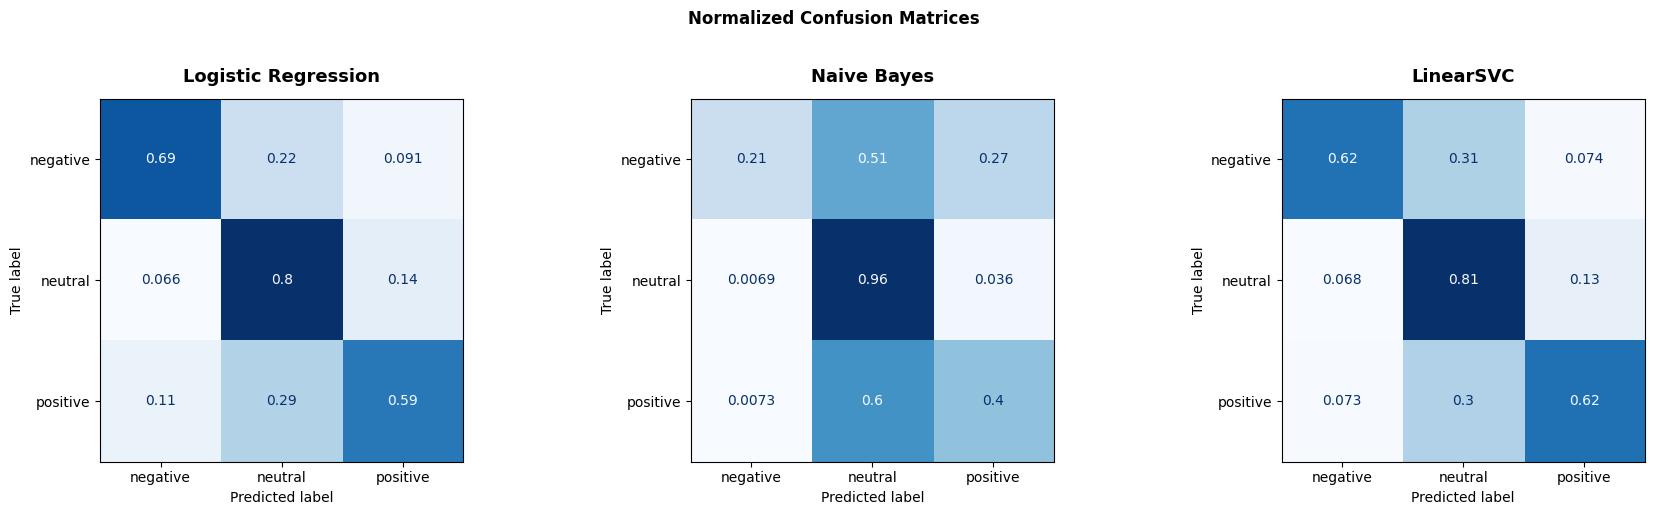

Chart saved.


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = ['Logistic Regression', 'Naive Bayes', 'LinearSVC']
trained_models = list(models.values())
labels = ['negative', 'neutral', 'positive']

for ax, model, name in zip(axes, trained_models, model_names):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Normalized Confusion Matrices', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

the confusion matrices make the Naive Bayes problem really visible - it's predicting neutral for almost everything, which is why neutral recall is 0.96 but negative recall is only 0.21. LinearSVC has the most balanced diagonal across all three classes. the positive vs neutral confusion is showing up in all three models though - positive headlines are getting misclassified as neutral pretty consistently. that's the overlap i flagged in the EDA.

In [5]:
# Error analysis on LinearSVC — best performing model
lsvc = models['LinearSVC']
y_pred_lsvc = lsvc.predict(X_test_tfidf)

# Add predictions to a dataframe
errors_df = X_test.copy().to_frame()
errors_df['true'] = y_test.values
errors_df['predicted'] = y_pred_lsvc

# Filter to misclassified examples
errors_df = errors_df[errors_df['true'] != errors_df['predicted']]

# Add original headline back
errors_df['headline'] = df.loc[errors_df.index, 'headline']

print(f"Total misclassified: {len(errors_df)} out of {len(y_test)} ({len(errors_df)/len(y_test)*100:.1f}%)")
print(f"\nMisclassification breakdown:")
print(errors_df.groupby(['true', 'predicted']).size().sort_values(ascending=False))

Total misclassified: 261 out of 970 (26.9%)

Misclassification breakdown:
true      predicted
positive  neutral      83
neutral   positive     73
          negative     39
negative  neutral      37
positive  negative     20
negative  positive      9
dtype: int64


In [6]:
# Look at the most dangerous errors — wrong direction
print("=== Negative predicted as Positive (dangerous for trading) ===")
neg_as_pos = errors_df[(errors_df['true'] == 'negative') & (errors_df['predicted'] == 'positive')]
for _, row in neg_as_pos.head(5).iterrows():
    print(f"  {row['headline']}")

print("\n=== Positive predicted as Negative ===")
pos_as_neg = errors_df[(errors_df['true'] == 'positive') & (errors_df['predicted'] == 'negative')]
for _, row in pos_as_neg.head(5).iterrows():
    print(f"  {row['headline']}")

=== Negative predicted as Positive (dangerous for trading) ===
  Seven-month sales of Ragutis , which is controlled by the Finnish brewery Olvi , declined by 11.2 percent , to 15.41 million liters , and the company held 9.89 percent of the market .
  At this growth rate , paying off the national debt will be extremely painful .
  Pretax profit totaled EUR 9.0 mn , down from EUR 36.3 mn in 2007 .
  TeliaSonera 's underlying results however included 457 mln skr in positive one-offs , hence the adjusted underlying EBITDA actually amounts to 7.309 bln skr , clearly below expectations , analysts said .
  Export declined by 6 percent to 16.4 million liters .

=== Positive predicted as Negative ===
  The diesel margin has remained high .
  The company expects its net sales in the first half of 2008 to reach the previous year 's level .
  More staff has been recruited in Japan to further complement its network of close to 50 service locations in more than 20 countries worldwide .
  Due to rapi

the dangerous misclassifications make the TF-IDF limitation really obvious. 'pretax profit totaled EUR 9.0 mn, down from EUR 36.3 mn' gets predicted as positive because the model sees 'profit' and completely ignores 'down'. and there's a headline with the word 'positive' literally in it that gets called positive even though it's describing a one-off adjustment in a negative report. TF-IDF just counts words, it has no concept of context or negation. this is the exact problem FinBERT is supposed to solve, so i'm curious whether it actually does.

## VADER Baseline

In [7]:
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Run VADER on test set — using original headlines, not preprocessed
vader_preds = df.loc[y_test.index, 'headline'].apply(vader_predict)

vader_f1 = f1_score(y_test, vader_preds, average='weighted')
print(f"VADER Weighted F1: {vader_f1:.4f}")
print(classification_report(y_test, vader_preds))

VADER Weighted F1: 0.5377
              precision    recall  f1-score   support

    negative       0.38      0.31      0.35       121
     neutral       0.74      0.50      0.60       576
    positive       0.38      0.68      0.49       273

    accuracy                           0.53       970
   macro avg       0.50      0.50      0.48       970
weighted avg       0.60      0.53      0.54       970



VADER scores 0.54 weighted F1 with no training at all, which is actually a reasonable sanity check - it means the task isn't trivially easy. but LinearSVC and LR both hit 0.73, which is a solid 18 point gap over the baseline. training on domain specific financial text clearly matters. VADER also struggles with neutral specifically, this makes sense since it's built for general sentiment and financial headlines tend to be technically neutral in tone even when the actual news is significant.

In [8]:
print("Model Comparison — Weighted F1")
print("-" * 35)
print(f"VADER (baseline):      {vader_f1:.4f}")
for name, f1 in results.items():
    print(f"{name:<25} {f1:.4f}")

Model Comparison — Weighted F1
-----------------------------------
VADER (baseline):      0.5377
Logistic Regression       0.7269
Naive Bayes               0.6662
LinearSVC                 0.7307


weighted F1 was my metric choice from the start because of the class imbalance, but i wanted to actually write out what it's measuring instead of just trusting sklearn's number.

for each class: F1 = 2 × (precision × recall) / (precision + recall). weighted F1 takes each class's F1 and multiplies it by that class's share of the test set, then sums them up. wait — i wasn't sure if "support" here meant training count or test count. turns out it's the test set count. so for neutral that's roughly 575 out of 970 test samples — almost 60%. that's why weighted F1 is so sensitive to how well the model handles neutral specifically. a model that's great on negative and positive but mediocre on neutral will still score badly overall, which is exactly the behavior i want given how dominant neutral is in this dataset.

## Saving Best Model

In [9]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save LinearSVC and TF-IDF vectorizer
joblib.dump(models['LinearSVC'], '../models/linearsvc_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

print("Saved:")
print("  models/linearsvc_model.pkl")
print("  models/tfidf_vectorizer.pkl")

Saved:
  models/linearsvc_model.pkl
  models/tfidf_vectorizer.pkl


## Findings
**What worked:**
- LinearSVC and Logistic Regression both hit 0.73 weighted F1 - a meaningful improvement over the VADER baseline (0.54)
- class_weight='balanced' made a real difference - Naive Bayes without it had negative recall of only 0.21
- TF-IDF with bigrams captured some phrase-level signal despite being a bag-of-words approach

**What didn't:**
- Positive/neutral confusion is the dominant failure mode across all three models - 83 positive headlines misclassified as neutral
- TF-IDF has no concept of negation or context - "profit down" and "profit up" look similar to it
- 29 cases where the model got direction completely wrong (positive↔negative) - the dangerous failure mode for trading

**What's next:**
- FinBERT should handle the negation and context problems - that's the whole point of a domain-specific transformer
- The real question is whether better NLP actually translates to better trading signals